# CACo Fine-Tuning: EuroSAT Classification

This notebook fine-tunes and evaluates CACo pre-trained backbones on the **EuroSAT** dataset using plain PyTorch (no pytorch-lightning).

**Task:** 10-class land cover classification (linear probing)

**Expected results from paper (ResNet-18, 100k):**

| Method | Top-1 Accuracy |
|---|---|
| Random Init | 64.21% |
| ImageNet | 86.16% |
| SeCo 100k | 90.05% |
| CACo 100k | **93.08%** |

## Step 1: Install Dependencies

For local VSCode use, this installs from `requirements-notebook-local.txt` when available.

In [ ]:
import subprocess
import sys
from pathlib import Path

def _find_root_for_requirements(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "requirements-notebook-local.txt").exists():
            return candidate
    return None

root = _find_root_for_requirements(Path.cwd())
if root is not None:
    req = root / "requirements-notebook-local.txt"
    print(f"Installing from {req}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", str(req)], check=True)
else:
    base_pkgs = [
        "torch", "torchvision", "matplotlib", "scikit-learn", "pillow",
        "tqdm", "pandas", "lmdb", "tifffile", "progressbar2", "ipykernel", "notebook",
    ]
    print("requirements-notebook-local.txt not found; installing fallback package list")
    subprocess.run([sys.executable, "-m", "pip", "install", *base_pkgs], check=True)

try:
    subprocess.run([sys.executable, "-m", "pip", "install", "rasterio"], check=True)
except subprocess.CalledProcessError:
    print("[warn] rasterio install failed; tifffile fallback remains available.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 27.0 MB/s eta 0:00:00


## Step 2: Locate Project / CACo Source

In [ ]:
import os
from pathlib import Path
import subprocess
import sys

def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "caco" / "src").exists():
            return candidate
    return None

project_root = find_project_root(Path.cwd())

if project_root is not None:
    caco_src = project_root / "caco" / "src"
    os.chdir(project_root)
    print(f"Using local repo CACo source: {caco_src}")

sys.path.insert(0, str(caco_src))
print('Done. CACo/src added to path.')

Cloning into 'CACo'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 59 (delta 16), reused 50 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 2.34 MiB | 50.92 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Done. CACo/src added to path.


## Step 3: Imports

In [ ]:
import shutil
from os.path import isdir, isfile, join
from os import mkdir
from urllib import request
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision import transforms as T
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils.pretrained_checkpoints import saved_torch_ckpts
from datasets.eurosat_dataset import EurosatDataset

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## Step 4: Download Pre-trained Weights

In [ ]:
CKPT_DIR = 'checkpoints'
CKPT_URL = 'https://research.cs.cornell.edu/caco/checkpoints/'

if not isdir(CKPT_DIR):
    mkdir(CKPT_DIR)

def download_checkpoint(ckpt_name):
    dest = join(CKPT_DIR, ckpt_name)
    if not isfile(dest):
        print(f'Downloading {ckpt_name} ...')
        request.urlretrieve(join(CKPT_URL, ckpt_name), dest)
        print('Done.')
    else:
        print(f'Already exists: {ckpt_name}')

# Download .pth files (plain PyTorch, no lightning needed)
for key in ['r18_100k_caco', 'r18_100k_seco']:
    download_checkpoint(saved_torch_ckpts[key])

print('\nAll checkpoints ready.')

Done.
Done.

All checkpoints ready.


## Step 5: Download EuroSAT Dataset

In [ ]:
DATA_DIR    = 'data'
EUROSAT_DIR = join(DATA_DIR, 'EuroSAT_RGB')
ZIP_PATH    = join(DATA_DIR, 'EuroSAT_RGB.zip')
DOWNLOAD_URL = 'https://research.cs.cornell.edu/caco/data/eurosat/EuroSAT_RGB.zip'
SPLIT_URL    = 'https://research.cs.cornell.edu/caco/data/eurosat'

if not isdir(DATA_DIR):
    mkdir(DATA_DIR)

if not isfile(ZIP_PATH):
    print('Downloading EuroSAT dataset (this may take a few minutes)...')
    request.urlretrieve(DOWNLOAD_URL, ZIP_PATH)
    print('Download complete.')

if not isdir(EUROSAT_DIR):
    print('Extracting...')
    shutil.unpack_archive(ZIP_PATH, DATA_DIR)
    print('Downloading split files...')
    for split in ['train.txt', 'val.txt', 'all.txt']:
        request.urlretrieve(join(SPLIT_URL, split), join(EUROSAT_DIR, split))

print('EuroSAT ready at:', EUROSAT_DIR)

Download complete.
Extracting...
EuroSAT ready at: data/EuroSAT_RGB


## Step 6: Create DataLoaders

In [ ]:
# Simple transforms: resize to 64x64 (EuroSAT native size) and normalize
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_dataset = EurosatDataset(EUROSAT_DIR, split='train', transform=transform)
val_dataset   = EurosatDataset(EUROSAT_DIR, split='val',   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)

NUM_CLASSES = 10
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples:   {len(val_dataset)}')
print(f'Classes: {train_dataset.classes}')

Train samples: 16200
Val samples:   5400
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Step 7: Helper Functions — Load Backbone and Train

In [ ]:
def load_backbone(backbone_type, ckpt_key=None):
    if backbone_type == 'random':
        model = resnet18(pretrained=False)
        backbone = nn.Sequential(*list(model.children())[:-1], nn.Flatten())

    elif backbone_type == 'imagenet':
        model = resnet18(pretrained=True)
        backbone = nn.Sequential(*list(model.children())[:-1], nn.Flatten())

    elif backbone_type == 'pretrain':
        # Build Sequential backbone FIRST
        model = resnet18(pretrained=False)
        backbone = nn.Sequential(*list(model.children())[:-1], nn.Flatten())
        # NOW load the weights — keys will match
        ckpt_path = join(CKPT_DIR, saved_torch_ckpts[ckpt_key])
        state_dict = torch.load(ckpt_path, map_location='cpu')
        result = backbone.load_state_dict(state_dict, strict=False)
        print(f'Loaded: {saved_torch_ckpts[ckpt_key]}')
        print(f'Missing keys: {result.missing_keys}')
        print(f'Unexpected keys: {result.unexpected_keys}')

    return backbone


def build_classifier(backbone, in_features=512, num_classes=10):
    """Freeze backbone, add a linear layer on top."""
    # Freeze all backbone parameters
    for param in backbone.parameters():
        param.requires_grad = False
    classifier = nn.Linear(in_features, num_classes)
    # Full model: frozen backbone + trainable linear layer
    model = nn.Sequential(backbone, classifier)
    return model


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total * 100


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total * 100


def run_experiment(name, backbone_type, ckpt_key=None, num_epochs=100):
    print(f'\n========== {name} ==========')
    backbone   = load_backbone(backbone_type, ckpt_key).to(device)
    model      = build_classifier(backbone).to(device)
    optimizer  = optim.Adam(model[-1].parameters())  # only train the linear layer
    criterion  = nn.CrossEntropyLoss()
    milestones = [int(0.6 * num_epochs), int(0.8 * num_epochs)]
    scheduler  = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones)

    best_val_acc = 0
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)
        scheduler.step()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Acc: {train_acc:.2f}% | '
                  f'Val Acc: {val_acc:.2f}%')

    print(f'  => Best Val Acc: {best_val_acc:.2f}%')
    return best_val_acc

print('Helper functions ready.')

Helper functions ready.


## Step 8: Run All Experiments

This will train 4 models one by one. Each takes ~5-10 minutes on Colab GPU.

In [ ]:
torch.manual_seed(42)

experiments = [
    ('Random Init', 'random',   None),
    ('ImageNet',    'imagenet', None),
    ('SeCo 100k',   'pretrain', 'r18_100k_seco'),
    ('CACo 100k',   'pretrain', 'r18_100k_caco'),
]

results = {}
for name, btype, ckpt_key in experiments:
    results[name] = run_experiment(name, btype, ckpt_key, num_epochs=100)


========== Random Init ==========


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Epoch  10/100 | Train Acc: 61.56% | Val Acc: 61.63%
  Epoch  20/100 | Train Acc: 63.71% | Val Acc: 62.39%
  Epoch  30/100 | Train Acc: 64.60% | Val Acc: 62.70%
  Epoch  40/100 | Train Acc: 64.80% | Val Acc: 62.37%
  Epoch  50/100 | Train Acc: 64.98% | Val Acc: 61.57%
  Epoch  60/100 | Train Acc: 65.38% | Val Acc: 62.33%
  Epoch  70/100 | Train Acc: 66.25% | Val Acc: 62.37%
  Epoch  80/100 | Train Acc: 66.61% | Val Acc: 62.98%
  Epoch  90/100 | Train Acc: 66.59% | Val Acc: 63.17%
  Epoch 100/100 | Train Acc: 66.81% | Val Acc: 62.80%
  => Best Val Acc: 63.33%

========== ImageNet ==========
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


  Epoch  10/100 | Train Acc: 86.70% | Val Acc: 85.85%
  Epoch  20/100 | Train Acc: 87.52% | Val Acc: 85.09%
  Epoch  30/100 | Train Acc: 87.25% | Val Acc: 85.63%
  Epoch  40/100 | Train Acc: 87.81% | Val Acc: 85.59%
  Epoch  50/100 | Train Acc: 87.98% | Val Acc: 84.69%
  Epoch  60/100 | Train Acc: 87.57% | Val Acc: 84.59%
  Epoch  70/100 | Train Acc: 88.69% | Val Acc: 85.65%
  Epoch  80/100 | Train Acc: 88.86% | Val Acc: 85.78%
  Epoch  90/100 | Train Acc: 88.96% | Val Acc: 85.96%
  Epoch 100/100 | Train Acc: 88.93% | Val Acc: 85.26%
  => Best Val Acc: 86.11%

========== SeCo 100k ==========
Loaded: resnet18_seco_geo_100k_1000.pth
Missing keys: []
Unexpected keys: []
  Epoch  10/100 | Train Acc: 91.85% | Val Acc: 92.13%
  Epoch  20/100 | Train Acc: 92.95% | Val Acc: 93.17%
  Epoch  30/100 | Train Acc: 93.49% | Val Acc: 93.19%
  Epoch  40/100 | Train Acc: 93.78% | Val Acc: 93.39%
  Epoch  50/100 | Train Acc: 94.06% | Val Acc: 93.20%
  Epoch  60/100 | Train Acc: 94.20% | Val Acc: 93.33%


## Step 9: Compare Results vs Paper

In [ ]:
paper_results = {
    'Random Init': 64.21,
    'ImageNet':    86.16,
    'SeCo 100k':   90.05,
    'CACo 100k':   93.08,
}

print(f"{'Method':<20} {'Ours':>10} {'Paper':>10} {'Diff':>10}")
print('-' * 52)
for name in paper_results:
    ours  = results.get(name, 0)
    paper = paper_results[name]
    diff  = ours - paper
    print(f'{name:<20} {ours:>10.2f} {paper:>10.2f} {diff:>+10.2f}')

Method                     Ours      Paper       Diff
----------------------------------------------------
Random Init               63.33      64.21      -0.88
ImageNet                  86.11      86.16      -0.05
SeCo 100k                 93.70      90.05      +3.65
CACo 100k                 93.65      93.08      +0.57


## Step 10: Plot Results

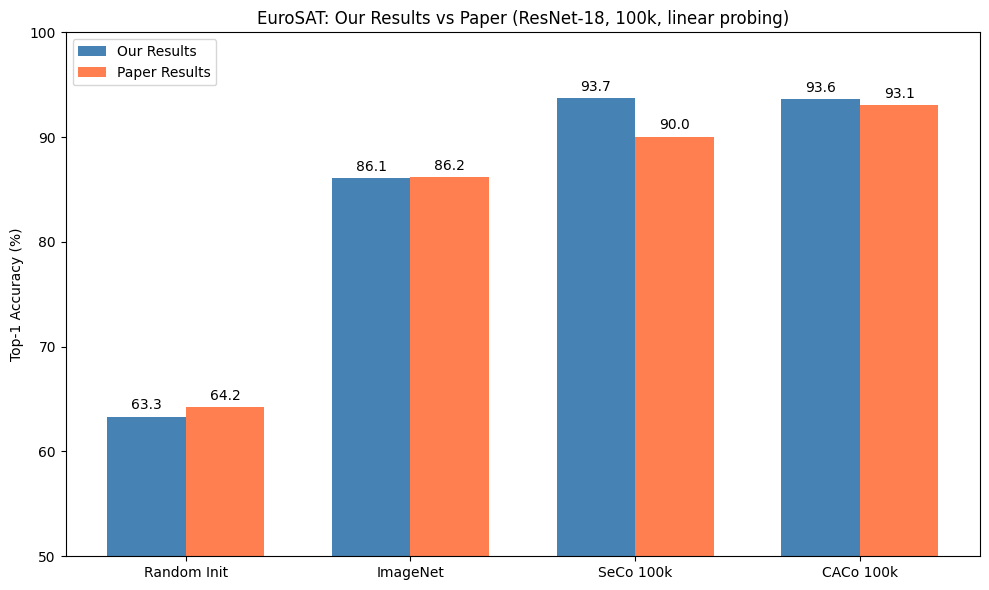

Saved to eurosat_results.png


In [ ]:
methods    = list(paper_results.keys())
our_vals   = [results.get(m, 0) for m in methods]
paper_vals = [paper_results[m]  for m in methods]

x     = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, our_vals,   width, label='Our Results',   color='steelblue')
bars2 = ax.bar(x + width/2, paper_vals, width, label='Paper Results', color='coral')

ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('EuroSAT: Our Results vs Paper (ResNet-18, 100k, linear probing)')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(50, 100)
ax.legend()
ax.bar_label(bars1, fmt='%.1f', padding=3)
ax.bar_label(bars2, fmt='%.1f', padding=3)

plt.tight_layout()
plt.savefig('eurosat_results.png', dpi=150)
plt.show()
print('Saved to eurosat_results.png')